# Clean Maven V2 - USA Only Daily Revenue Analysis

Notebook này là version Maven Market chỉ lọc **USA stores** để scope gần hơn với M5.

Scope v2:

```text
US grocery/retail stores, observed store-day revenue, 1997-1998
```

Target chính:

```text
observed date + store_id -> net_revenue
```

Cách tính:

```text
gross_revenue = quantity * product_retail_price
return_value = return_quantity * product_retail_price
net_revenue = gross_revenue - return_value
```

Lưu ý Data Science:

- Maven không phải panel bán hàng đầy đủ như M5.
- Nếu một `date-store` không xuất hiện trong transaction, chưa chắc doanh thu thật bằng 0.
- Vì vậy bảng chính dùng **observed store-day**, còn panel đầy đủ chỉ dùng để cảnh báo coverage/selection bias.

## Cell 1 - Import và khai báo đường dẫn

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd
for candidate in [cwd, *cwd.parents]:
    if (candidate / "data" / "Maven Market Datasets").exists():
        PROJECT_ROOT = candidate
        break

DATA_DIR = PROJECT_ROOT / "data" / "Maven Market Datasets"

CALENDAR_PATH = DATA_DIR / "MavenMarket_Calendar.csv"
CUSTOMERS_PATH = DATA_DIR / "MavenMarket_Customers.csv"
PRODUCTS_PATH = DATA_DIR / "MavenMarket_Products.csv"
REGIONS_PATH = DATA_DIR / "MavenMarket_Regions.csv"
RETURNS_PATH = DATA_DIR / "MavenMarket_Returns_1997-1998.csv"
STORES_PATH = DATA_DIR / "MavenMarket_Stores.csv"
TXN_1997_PATH = DATA_DIR / "MavenMarket_Transactions_1997.csv"
TXN_1998_PATH = DATA_DIR / "MavenMarket_Transactions_1998.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
for path in [CALENDAR_PATH, CUSTOMERS_PATH, PRODUCTS_PATH, REGIONS_PATH, RETURNS_PATH, STORES_PATH, TXN_1997_PATH, TXN_1998_PATH]:
    print(path.name, path.exists())

PROJECT_ROOT: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project
DATA_DIR: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets
MavenMarket_Calendar.csv True
MavenMarket_Customers.csv True
MavenMarket_Products.csv True
MavenMarket_Regions.csv True
MavenMarket_Returns_1997-1998.csv True
MavenMarket_Stores.csv True
MavenMarket_Transactions_1997.csv True
MavenMarket_Transactions_1998.csv True


## Cell 2 - Đọc dữ liệu gốc

Cell này đọc các bảng Maven và thống kê kích thước ban đầu.

In [2]:
calendar_raw = pd.read_csv(CALENDAR_PATH)
customers_raw = pd.read_csv(CUSTOMERS_PATH)
products_raw = pd.read_csv(PRODUCTS_PATH)
regions_raw = pd.read_csv(REGIONS_PATH)
returns_raw = pd.read_csv(RETURNS_PATH)
stores_raw = pd.read_csv(STORES_PATH)
txn_1997_raw = pd.read_csv(TXN_1997_PATH)
txn_1998_raw = pd.read_csv(TXN_1998_PATH)

raw_tables = {
    "calendar": calendar_raw,
    "customers": customers_raw,
    "products": products_raw,
    "regions": regions_raw,
    "returns": returns_raw,
    "stores": stores_raw,
    "txn_1997": txn_1997_raw,
    "txn_1998": txn_1998_raw,
}

overview = []
for name, df in raw_tables.items():
    overview.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    })

display(pd.DataFrame(overview))
display(stores_raw[["store_id", "store_name", "store_city", "store_state", "store_country", "store_type"]].sort_values("store_id"))

,table,rows,columns,missing_cells,duplicate_rows
0,calendar,730,1,0,0
1,customers,10281,20,1,0
2,products,1560,9,1695,0
3,regions,109,3,0,0
4,returns,7087,4,0,5
5,stores,24,13,0,0
6,txn_1997,86837,6,0,1
7,txn_1998,182883,6,0,8


,store_id,store_name,store_city,store_state,store_country,store_type
0,1,Store 1,Acapulco,Guerrero,Mexico,Supermarket
1,2,Store 2,Bellingham,WA,USA,Small Grocery
2,3,Store 3,Bremerton,WA,USA,Supermarket
3,4,Store 4,Camacho,Zacatecas,Mexico,Gourmet Supermarket
4,5,Store 5,Guadalajara,Jalisco,Mexico,Small Grocery
5,6,Store 6,Beverly Hills,CA,USA,Gourmet Supermarket
6,7,Store 7,Los Angeles,CA,USA,Supermarket
7,8,Store 8,Merida,Yucatan,Mexico,Deluxe Supermarket
8,9,Store 9,Mexico City,DF,Mexico,Mid-Size Grocery
9,10,Store 10,Orizaba,Veracruz,Mexico,Supermarket


## Cell 3 - Chuẩn hóa calendar và dimension tables

Cell này tạo time features, làm sạch product/store/customer. Các feature này sẽ dùng cho phân tích và baseline model sau.

In [3]:
calendar = calendar_raw.copy()
calendar["date"] = pd.to_datetime(calendar["date"])
calendar["year"] = calendar["date"].dt.year.astype("int16")
calendar["month"] = calendar["date"].dt.month.astype("int8")
calendar["quarter"] = calendar["date"].dt.quarter.astype("int8")
calendar["week_of_year"] = calendar["date"].dt.isocalendar().week.astype("int16")
calendar["day_of_month"] = calendar["date"].dt.day.astype("int8")
calendar["day_of_year"] = calendar["date"].dt.dayofyear.astype("int16")
calendar["day_of_week"] = calendar["date"].dt.day_name()
calendar["day_of_week_num"] = calendar["date"].dt.dayofweek.astype("int8")
calendar["is_weekend"] = calendar["day_of_week_num"].isin([5, 6]).astype("int8")
calendar["year_month"] = calendar["date"].dt.to_period("M").astype(str)

products = products_raw.copy()
products["recyclable"] = products["recyclable"].fillna(0).astype("int8")
products["low_fat"] = products["low_fat"].fillna(0).astype("int8")
products["gross_margin_per_unit"] = products["product_retail_price"] - products["product_cost"]
products["gross_margin_pct"] = np.where(products["product_retail_price"].gt(0), products["gross_margin_per_unit"] / products["product_retail_price"], np.nan)

regions = regions_raw.copy()

stores = stores_raw.copy()
stores["first_opened_date"] = pd.to_datetime(stores["first_opened_date"])
stores["last_remodel_date"] = pd.to_datetime(stores["last_remodel_date"])
stores["grocery_sqft_ratio"] = stores["grocery_sqft"] / stores["total_sqft"]
stores = stores.merge(regions, on="region_id", how="left", validate="many_to_one")

customers = customers_raw.copy()
customers["birthdate"] = pd.to_datetime(customers["birthdate"], errors="coerce")
customers["acct_open_date"] = pd.to_datetime(customers["acct_open_date"], errors="coerce")
customers["last_name"] = customers["last_name"].fillna("Unknown")

print("calendar date range:", calendar["date"].min(), "->", calendar["date"].max())
print("products:", products.shape, "brands:", products["product_brand"].nunique())
print("stores:", stores.shape)
print("customers:", customers.shape)

calendar date range: 1997-01-01 00:00:00 -> 1998-12-31 00:00:00
products: (1560, 11) brands: 111
stores: (24, 16)
customers: (10281, 20)


## Cell 4 - Lọc USA stores

Cell này là điểm khác biệt chính của v2: chỉ giữ các cửa hàng ở Mỹ.

In [4]:
usa_stores = stores.loc[stores["store_country"].eq("USA")].copy()
usa_store_ids = sorted(usa_stores["store_id"].unique().tolist())

print("USA stores:", len(usa_store_ids))
print("USA store ids:", usa_store_ids)
print("USA states:", sorted(usa_stores["store_state"].unique().tolist()))
print("USA cities:", sorted(usa_stores["store_city"].unique().tolist()))

display(usa_stores[["store_id", "store_name", "store_type", "store_city", "store_state", "store_country", "total_sqft", "grocery_sqft", "sales_region"]].sort_values("store_id"))

USA stores: 13
USA store ids: [2, 3, 6, 7, 11, 13, 14, 15, 16, 17, 22, 23, 24]
USA states: ['CA', 'OR', 'WA']
USA cities: ['Bellingham', 'Beverly Hills', 'Bremerton', 'Los Angeles', 'Portland', 'Salem', 'San Diego', 'San Francisco', 'Seattle', 'Spokane', 'Tacoma', 'Walla Walla', 'Yakima']


,store_id,store_name,store_type,store_city,store_state,store_country,total_sqft,grocery_sqft,sales_region
1,2,Store 2,Small Grocery,Bellingham,WA,USA,28206,22271,North West
2,3,Store 3,Supermarket,Bremerton,WA,USA,39696,24390,North West
5,6,Store 6,Gourmet Supermarket,Beverly Hills,CA,USA,23688,15337,South West
6,7,Store 7,Supermarket,Los Angeles,CA,USA,23598,14210,South West
10,11,Store 11,Supermarket,Portland,OR,USA,20319,16232,North West
12,13,Store 13,Deluxe Supermarket,Salem,OR,USA,27694,18670,North West
13,14,Store 14,Small Grocery,San Francisco,CA,USA,22478,15321,Central West
14,15,Store 15,Supermarket,Seattle,WA,USA,21215,13305,North West
15,16,Store 16,Supermarket,Spokane,WA,USA,30268,22063,North West
16,17,Store 17,Deluxe Supermarket,Tacoma,WA,USA,33858,22123,North West


## Cell 5 - Gộp transactions và lọc USA

Cell này nối transactions 1997/1998, sau đó lọc chỉ các `store_id` thuộc USA.

In [5]:
txn_1997 = txn_1997_raw.copy()
txn_1998 = txn_1998_raw.copy()
txn_1997["source_year_file"] = 1997
txn_1998["source_year_file"] = 1998

transactions_all = pd.concat([txn_1997, txn_1998], ignore_index=True)
transactions_all["transaction_date"] = pd.to_datetime(transactions_all["transaction_date"])
transactions_all["stock_date"] = pd.to_datetime(transactions_all["stock_date"])

transactions_us = transactions_all.loc[transactions_all["store_id"].isin(usa_store_ids)].copy()

print("All transactions:", transactions_all.shape)
print("USA transactions:", transactions_us.shape)
print("USA transaction date range:", transactions_us["transaction_date"].min(), "->", transactions_us["transaction_date"].max())
print("USA stores by transaction year:")
display(transactions_us.assign(year=transactions_us["transaction_date"].dt.year).groupby("year")["store_id"].nunique().reset_index(name="store_count"))
print("Rows share USA (%):", len(transactions_us) / len(transactions_all) * 100)
display(transactions_us.head())

All transactions: (269720, 7)
USA transactions: (180823, 7)
USA transaction date range: 1997-01-01 00:00:00 -> 1998-12-30 00:00:00
USA stores by transaction year:


,year,store_count
0,1997,13
1,1998,13


Rows share USA (%): 67.04100548717187


,transaction_date,stock_date,product_id,customer_id,store_id,quantity,source_year_file
0,1997-01-01,1996-12-31,869,3449,6,5,1997
1,1997-01-01,1996-12-31,1472,3449,6,3,1997
2,1997-01-01,1996-12-28,76,3449,6,4,1997
3,1997-01-01,1996-12-26,320,3449,6,3,1997
4,1997-01-01,1996-12-25,4,3449,6,4,1997


## Cell 6 - Join USA transactions với product/store/customer

Cell này tạo bảng line item đầy đủ cho USA và tính doanh thu gộp.

In [6]:
line_items_us = transactions_us.merge(products, on="product_id", how="left", validate="many_to_one")
line_items_us = line_items_us.merge(usa_stores, on="store_id", how="left", validate="many_to_one")
line_items_us = line_items_us.merge(customers, on="customer_id", how="left", validate="many_to_one")

line_items_us["gross_revenue"] = line_items_us["quantity"] * line_items_us["product_retail_price"]
line_items_us["gross_cost"] = line_items_us["quantity"] * line_items_us["product_cost"]
line_items_us["gross_profit"] = line_items_us["gross_revenue"] - line_items_us["gross_cost"]
line_items_us["gross_margin_pct_line"] = np.where(line_items_us["gross_revenue"].gt(0), line_items_us["gross_profit"] / line_items_us["gross_revenue"], np.nan)
line_items_us["customer_age"] = (line_items_us["transaction_date"] - line_items_us["birthdate"]).dt.days / 365.25
line_items_us["customer_account_age_days"] = (line_items_us["transaction_date"] - line_items_us["acct_open_date"]).dt.days

join_quality = pd.DataFrame([
    ("rows", len(line_items_us)),
    ("missing_product_rows", int(line_items_us["product_brand"].isna().sum())),
    ("missing_store_rows", int(line_items_us["store_name"].isna().sum())),
    ("missing_customer_rows", int(line_items_us["first_name"].isna().sum())),
    ("negative_revenue_rows", int(line_items_us["gross_revenue"].lt(0).sum())),
    ("zero_revenue_rows", int(line_items_us["gross_revenue"].eq(0).sum())),
], columns=["metric", "value"])

display(join_quality)
display(line_items_us.head())

,metric,value
0,rows,180823
1,missing_product_rows,0
2,missing_store_rows,0
3,missing_customer_rows,0
4,negative_revenue_rows,0
5,zero_revenue_rows,0


,transaction_date,stock_date,product_id,customer_id,store_id,quantity,source_year_file,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,gross_margin_per_unit,gross_margin_pct,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,grocery_sqft_ratio,sales_district,sales_region,customer_acct_num,first_name,last_name,customer_address,customer_city,customer_state_province,customer_postal_code,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner,gross_revenue,gross_cost,gross_profit,gross_margin_pct_line,customer_age,customer_account_age_days
0,1997-01-01,1996-12-31,869,3449,6,5,1997,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.120,0.910,17.000,1,0,1.210,0.571,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,10.600,4.550,6.050,0.571,17.101,756
1,1997-01-01,1996-12-31,1472,3449,6,3,1997,Fort West,Fort West Fudge Cookies,37276054024,2.200,0.900,8.280,1,0,1.300,0.591,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,6.600,2.700,3.900,0.591,17.101,756
2,1997-01-01,1996-12-28,76,3449,6,4,1997,Red Spade,Red Spade Sliced Chicken,62054644227,1.690,0.690,18.100,0,1,1.000,0.592,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,6.760,2.760,4.000,0.592,17.101,756
3,1997-01-01,1996-12-26,320,3449,6,3,1997,Excellent,Excellent Cranberry Juice,36570182442,3.260,1.080,16.400,0,0,2.180,0.669,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,9.780,3.240,6.540,0.669,17.101,756
4,1997-01-01,1996-12-25,4,3449,6,4,1997,Washington,Washington Cream Soda,64412155747,3.640,1.640,10.600,1,0,2.000,0.549,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,14.560,6.560,8.000,0.549,17.101,756


## Cell 7 - Xử lý returns USA

Cell này lọc returns của USA và tính `return_value`.

In [7]:
returns_all = returns_raw.copy()
returns_all["return_date"] = pd.to_datetime(returns_all["return_date"])
returns_us = returns_all.loc[returns_all["store_id"].isin(usa_store_ids)].copy()
returns_us = returns_us.merge(products, on="product_id", how="left", validate="many_to_one")
returns_us = returns_us.merge(usa_stores, on="store_id", how="left", validate="many_to_one")
returns_us["return_value"] = returns_us["quantity"] * returns_us["product_retail_price"]
returns_us["return_cost"] = returns_us["quantity"] * returns_us["product_cost"]

return_quality = pd.DataFrame([
    ("all_return_rows", len(returns_all)),
    ("usa_return_rows", len(returns_us)),
    ("missing_product_rows", int(returns_us["product_brand"].isna().sum())),
    ("missing_store_rows", int(returns_us["store_name"].isna().sum())),
    ("negative_return_value_rows", int(returns_us["return_value"].lt(0).sum())),
], columns=["metric", "value"])

display(return_quality)
display(returns_us.head())

,metric,value
0,all_return_rows,7087
1,usa_return_rows,4645
2,missing_product_rows,0
3,missing_store_rows,0
4,negative_return_value_rows,0


,return_date,product_id,store_id,quantity,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,gross_margin_per_unit,gross_margin_pct,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,grocery_sqft_ratio,sales_district,sales_region,return_value,return_cost
0,1997-01-01,250,6,1,Best Choice,Best Choice Golden Raisins,95335729718,2.590,0.830,13.400,0,0,1.760,0.680,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,2.590,0.830
1,1997-01-01,628,6,1,Token,Token Cola,48011456131,1.400,0.520,16.400,1,0,0.880,0.629,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,1.400,0.520
2,1997-01-01,869,6,1,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.120,0.910,17.000,1,0,1.210,0.571,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,0.647,Los Angeles,South West,2.120,0.910
3,1997-01-02,469,11,1,Red Wing,Red Wing Silver Cleaner,87961875796,1.290,0.580,8.030,1,0,0.710,0.550,22,Supermarket,Store 11,5371 Holland Circle,Portland,OR,USA,685-555-8995,1976-09-17,1982-05-15,20319,16232,0.799,Portland,North West,1.290,0.580
4,1997-01-02,532,23,2,Fast,Fast Sugar Cookies,56197987198,3.870,1.390,21.700,1,0,2.480,0.641,89,Mid-Size Grocery,Store 23,3920 Noah Court,Yakima,WA,USA,170-555-8424,1977-07-16,1987-07-24,29182,19283,0.661,Yakima,North West,7.740,2.780


## Cell 8 - Aggregate sales và returns theo observed date-store

Cell này tạo target chính `net_revenue` ở cấp `observed date + store_id`.

In [8]:
sales_store_daily_us = (
    line_items_us.groupby(["transaction_date", "store_id"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        gross_cost=("gross_cost", "sum"),
        gross_profit=("gross_profit", "sum"),
        quantity_sold=("quantity", "sum"),
        line_item_count=("product_id", "size"),
        distinct_products_sold=("product_id", "nunique"),
        distinct_brands_sold=("product_brand", "nunique"),
        distinct_customers=("customer_id", "nunique"),
        avg_customer_age=("customer_age", "mean"),
        avg_unit_retail_price=("product_retail_price", "mean"),
        avg_margin_pct_line=("gross_margin_pct_line", "mean"),
    )
    .rename(columns={"transaction_date": "date"})
)

returns_store_daily_us = (
    returns_us.groupby(["return_date", "store_id"], as_index=False)
    .agg(
        return_quantity=("quantity", "sum"),
        return_value=("return_value", "sum"),
        return_cost=("return_cost", "sum"),
        returned_product_count=("product_id", "nunique"),
    )
    .rename(columns={"return_date": "date"})
)

maven_us_daily = sales_store_daily_us.merge(
    returns_store_daily_us,
    on=["date", "store_id"],
    how="outer",
    validate="one_to_one",
)

metric_cols = [
    "gross_revenue", "gross_cost", "gross_profit", "quantity_sold", "line_item_count", "distinct_products_sold", "distinct_brands_sold", "distinct_customers",
    "return_quantity", "return_value", "return_cost", "returned_product_count",
]
for col in metric_cols:
    maven_us_daily[col] = maven_us_daily[col].fillna(0)

maven_us_daily = maven_us_daily.merge(
    calendar[["date", "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "year_month", "day_of_week", "day_of_week_num", "is_weekend"]],
    on="date",
    how="left",
    validate="many_to_one",
)
maven_us_daily = maven_us_daily.merge(
    usa_stores[["store_id", "region_id", "store_type", "store_name", "store_city", "store_state", "store_country", "sales_district", "sales_region", "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "first_opened_date", "last_remodel_date"]],
    on="store_id",
    how="left",
    validate="many_to_one",
)

store_observed_period_us = transactions_us.groupby("store_id", as_index=False).agg(
    first_observed_transaction_date=("transaction_date", "min"),
    last_observed_transaction_date=("transaction_date", "max"),
    observed_transaction_rows=("transaction_date", "size"),
)
maven_us_daily = maven_us_daily.merge(store_observed_period_us, on="store_id", how="left", validate="many_to_one")

maven_us_daily["store_age_years"] = (maven_us_daily["date"] - maven_us_daily["first_opened_date"]).dt.days / 365.25
maven_us_daily["days_since_remodel"] = (maven_us_daily["date"] - maven_us_daily["last_remodel_date"]).dt.days
maven_us_daily["net_revenue"] = maven_us_daily["gross_revenue"] - maven_us_daily["return_value"]
maven_us_daily["net_profit"] = maven_us_daily["gross_profit"] - (maven_us_daily["return_value"] - maven_us_daily["return_cost"])
maven_us_daily["return_rate_value"] = np.where(maven_us_daily["gross_revenue"].gt(0), maven_us_daily["return_value"] / maven_us_daily["gross_revenue"], np.nan)
maven_us_daily["has_sales"] = maven_us_daily["gross_revenue"].gt(0).astype("int8")
maven_us_daily["has_returns"] = maven_us_daily["return_value"].gt(0).astype("int8")
maven_us_daily["log1p_net_revenue"] = np.log1p(np.clip(maven_us_daily["net_revenue"], a_min=0, a_max=None))
maven_us_daily["source_dataset"] = "maven_market_us"

preferred_cols = [
    "source_dataset", "date", "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "year_month", "day_of_week", "day_of_week_num", "is_weekend",
    "store_id", "store_name", "store_type", "store_city", "store_state", "store_country", "sales_district", "sales_region",
    "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "store_age_years", "days_since_remodel", "first_observed_transaction_date", "last_observed_transaction_date",
    "gross_revenue", "return_value", "net_revenue", "log1p_net_revenue", "gross_cost", "gross_profit", "net_profit",
    "quantity_sold", "line_item_count", "distinct_products_sold", "distinct_brands_sold", "distinct_customers", "avg_customer_age", "avg_unit_retail_price", "avg_margin_pct_line",
    "return_quantity", "returned_product_count", "return_rate_value", "has_sales", "has_returns",
]

maven_us_daily = maven_us_daily[preferred_cols].sort_values(["date", "store_id"]).reset_index(drop=True)

print("sales_store_daily_us:", sales_store_daily_us.shape)
print("returns_store_daily_us:", returns_store_daily_us.shape)
print("maven_us_daily:", maven_us_daily.shape)
display(maven_us_daily.head())
display(maven_us_daily.tail())

sales_store_daily_us: (1560, 13)
returns_store_daily_us: (1149, 6)
maven_us_daily: (1560, 47)


,source_dataset,date,year,month,quarter,week_of_year,day_of_month,day_of_year,year_month,day_of_week,day_of_week_num,is_weekend,store_id,store_name,store_type,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,grocery_sqft_ratio,store_age_years,days_since_remodel,first_observed_transaction_date,last_observed_transaction_date,gross_revenue,return_value,net_revenue,log1p_net_revenue,gross_cost,gross_profit,net_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line,return_quantity,returned_product_count,return_rate_value,has_sales,has_returns
0,maven_market_us,1997-01-01,1997,1,1,1,1,1,1997-01,Wednesday,2,0,6,Store 6,Gourmet Supermarket,Beverly Hills,CA,USA,Los Angeles,South West,23688,15337,0.647,15.995,2121,1997-01-01,1998-12-28,659.430,6.110,653.320,6.484,268.680,390.750,386.900,324,99,99,49,22,51.463,1.991,0.592,3.000,3.000,0.009,1,1
1,maven_market_us,1997-01-01,1997,1,1,1,1,1,1997-01,Wednesday,2,0,14,Store 14,Small Grocery,San Francisco,CA,USA,San Francisco,Central West,22478,15321,0.682,39.105,14239,1997-01-01,1998-12-29,46.910,0.000,46.910,3.869,19.500,27.410,27.410,24,18,18,15,4,30.778,2.008,0.590,0.000,0.000,0.000,1,0
2,maven_market_us,1997-01-02,1997,1,1,1,2,2,1997-01,Thursday,3,0,11,Store 11,Supermarket,Portland,OR,USA,Portland,North West,20319,16232,0.799,20.293,5346,1997-01-02,1998-12-30,882.940,5.640,877.300,6.778,347.240,535.700,532.310,431,140,135,61,32,50.173,2.066,0.608,3.000,3.000,0.006,1,1
3,maven_market_us,1997-01-02,1997,1,1,1,2,2,1997-01,Thursday,3,0,23,Store 23,Mid-Size Grocery,Yakima,WA,USA,Yakima,North West,29182,19283,0.661,19.466,3450,1997-01-02,1998-12-26,421.590,10.210,411.380,6.022,173.920,247.670,241.030,204,66,64,41,14,55.514,2.032,0.587,3.000,2.000,0.024,1,1
4,maven_market_us,1997-01-03,1997,1,1,1,3,3,1997-01,Friday,4,0,7,Store 7,Supermarket,Los Angeles,CA,USA,Los Angeles,South West,23598,14210,0.602,25.624,5554,1997-01-03,1998-12-20,867.640,15.260,852.380,6.749,354.080,513.560,503.900,394,128,124,58,30,54.559,2.186,0.595,5.000,4.000,0.018,1,1


,source_dataset,date,year,month,quarter,week_of_year,day_of_month,day_of_year,year_month,day_of_week,day_of_week_num,is_weekend,store_id,store_name,store_type,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,grocery_sqft_ratio,store_age_years,days_since_remodel,first_observed_transaction_date,last_observed_transaction_date,gross_revenue,return_value,net_revenue,log1p_net_revenue,gross_cost,gross_profit,net_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line,return_quantity,returned_product_count,return_rate_value,has_sales,has_returns
1555,maven_market_us,1998-12-27,1998,12,4,52,27,361,1998-12,Sunday,6,1,16,Store 16,Supermarket,Spokane,WA,USA,Spokane,North West,30268,22063,0.729,24.345,7837,1997-01-13,1998-12-27,"1,089.590",5.600,"1,083.990",6.989,441.450,648.140,644.790,521,164,158,60,30,58.915,2.086,0.597,3.000,3.000,0.005,1,1
1556,maven_market_us,1998-12-28,1998,12,4,53,28,362,1998-12,Monday,0,0,6,Store 6,Gourmet Supermarket,Beverly Hills,CA,USA,Los Angeles,South West,23688,15337,0.647,17.982,2847,1997-01-01,1998-12-28,879.750,9.590,870.160,6.770,355.700,524.050,518.450,413,136,130,59,29,46.371,2.142,0.596,4.000,3.000,0.011,1,1
1557,maven_market_us,1998-12-29,1998,12,4,53,29,363,1998-12,Tuesday,1,0,14,Store 14,Small Grocery,San Francisco,CA,USA,San Francisco,Central West,22478,15321,0.682,41.095,14966,1997-01-01,1998-12-29,143.860,0.000,143.860,4.976,57.120,86.740,86.740,61,31,31,27,8,58.854,2.370,0.612,0.000,0.000,0.000,1,0
1558,maven_market_us,1998-12-29,1998,12,4,53,29,363,1998-12,Tuesday,1,0,17,Store 17,Deluxe Supermarket,Tacoma,WA,USA,Tacoma,North West,33858,22123,0.653,28.583,8224,1997-01-11,1998-12-29,"1,564.250",10.050,"1,554.200",7.349,629.440,934.810,928.990,719,228,218,72,49,50.586,2.163,0.599,4.000,3.000,0.006,1,1
1559,maven_market_us,1998-12-30,1998,12,4,53,30,364,1998-12,Wednesday,2,0,11,Store 11,Supermarket,Portland,OR,USA,Portland,North West,20319,16232,0.799,22.283,6073,1997-01-02,1998-12-30,919.360,25.820,893.540,6.796,369.390,549.970,535.270,454,142,141,63,38,54.831,1.999,0.598,11.000,8.000,0.028,1,1


## Cell 9 - Kiểm tra panel sparsity USA

Cell này kiểm tra nếu tạo panel `date x store` đầy đủ thì có bao nhiêu false zero tiềm năng. Đây là lý do dùng observed store-day làm bảng chính.

In [9]:
grid_parts = []
for _, row in usa_stores.merge(store_observed_period_us, on="store_id", how="left").iterrows():
    dates = calendar.loc[
        (calendar["date"] >= row["first_observed_transaction_date"]) &
        (calendar["date"] <= calendar["date"].max()),
        ["date"],
    ].copy()
    dates["store_id"] = row["store_id"]
    grid_parts.append(dates)

usa_panel_grid = pd.concat(grid_parts, ignore_index=True)
usa_panel = usa_panel_grid.merge(sales_store_daily_us[["date", "store_id", "gross_revenue"]], on=["date", "store_id"], how="left")
usa_panel["gross_revenue"] = usa_panel["gross_revenue"].fillna(0)

panel_summary = pd.DataFrame([
    ("panel_rows", len(usa_panel)),
    ("observed_store_day_rows", len(maven_us_daily)),
    ("panel_zero_revenue_rows", int(usa_panel["gross_revenue"].eq(0).sum())),
    ("panel_zero_revenue_pct", usa_panel["gross_revenue"].eq(0).mean() * 100),
], columns=["metric", "value"])

display(panel_summary)

,metric,value
0,panel_rows,"9,430.000"
1,observed_store_day_rows,"1,560.000"
2,panel_zero_revenue_rows,"7,870.000"
3,panel_zero_revenue_pct,83.457


## Cell 10 - Data quality check

In [10]:
quality_summary = pd.DataFrame([
    ("rows", len(maven_us_daily)),
    ("unique_dates", maven_us_daily["date"].nunique()),
    ("unique_stores", maven_us_daily["store_id"].nunique()),
    ("unique_states", maven_us_daily["store_state"].nunique()),
    ("duplicate_date_store_keys", int(maven_us_daily.duplicated(["date", "store_id"]).sum())),
    ("missing_net_revenue", int(maven_us_daily["net_revenue"].isna().sum())),
    ("negative_net_revenue_rows", int(maven_us_daily["net_revenue"].lt(0).sum())),
    ("return_gt_gross_rows", int(maven_us_daily["return_value"].gt(maven_us_daily["gross_revenue"]).sum())),
    ("zero_gross_revenue_rows", int(maven_us_daily["gross_revenue"].eq(0).sum())),
], columns=["metric", "value"])

display(quality_summary)
missing_summary = maven_us_daily.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "column"}).query("missing_count > 0")
display(missing_summary)

,metric,value
0,rows,1560
1,unique_dates,649
2,unique_stores,13
3,unique_states,3
4,duplicate_date_store_keys,0
5,missing_net_revenue,0
6,negative_net_revenue_rows,0
7,return_gt_gross_rows,0
8,zero_gross_revenue_rows,0


,column,missing_count


## Cell 11 - Thống kê tổng thể USA

In [11]:
overall_stats = pd.DataFrame([
    ("total_gross_revenue", maven_us_daily["gross_revenue"].sum()),
    ("total_return_value", maven_us_daily["return_value"].sum()),
    ("total_net_revenue", maven_us_daily["net_revenue"].sum()),
    ("total_quantity_sold", maven_us_daily["quantity_sold"].sum()),
    ("mean_net_revenue_per_store_day", maven_us_daily["net_revenue"].mean()),
    ("median_net_revenue_per_store_day", maven_us_daily["net_revenue"].median()),
    ("max_net_revenue_per_store_day", maven_us_daily["net_revenue"].max()),
    ("return_day_pct", maven_us_daily["has_returns"].mean() * 100),
    ("return_value_rate_pct", maven_us_daily["return_value"].sum() / maven_us_daily["gross_revenue"].sum() * 100),
], columns=["metric", "value"])

display(overall_stats)
display(maven_us_daily[["gross_revenue", "return_value", "net_revenue", "quantity_sold", "line_item_count", "distinct_customers", "distinct_products_sold", "return_rate_value"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

,metric,value
0,total_gross_revenue,"1,177,956.440"
1,total_return_value,"11,378.540"
2,total_net_revenue,"1,166,577.900"
3,total_quantity_sold,"555,899.000"
4,mean_net_revenue_per_store_day,747.806
5,median_net_revenue_per_store_day,823.780
6,max_net_revenue_per_store_day,"4,606.710"
7,return_day_pct,73.654
8,return_value_rate_pct,0.966


,gross_revenue,return_value,net_revenue,quantity_sold,line_item_count,distinct_customers,distinct_products_sold,return_rate_value
count,"1,560.000","1,560.000","1,560.000","1,560.000","1,560.000","1,560.000","1,560.000","1,560.000"
mean,755.100,7.294,747.806,356.346,115.912,26.069,111.215,0.008
std,499.682,6.870,494.639,235.813,71.865,15.745,65.897,0.007
min,22.540,0.000,22.540,11.000,6.000,3.000,6.000,0.000
1%,42.738,0.000,42.738,21.000,13.000,4.000,13.000,0.000
5%,58.564,0.000,58.564,28.000,18.000,5.000,18.000,0.000
25%,323.935,0.000,318.180,154.750,50.000,11.000,50.000,0.000
50%,830.885,6.115,823.780,391.000,124.000,28.000,120.000,0.007
75%,"1,046.243",11.552,"1,035.372",492.000,156.000,35.000,151.000,0.012
95%,"1,506.848",19.890,"1,496.589",706.000,222.000,49.000,209.000,0.020


## Cell 12 - Bias và variation audit cho Maven USA

In [12]:
bias_audit = pd.DataFrame([
    ("Coverage bias", "Trung bình", "Maven USA chỉ gồm 13 stores ở CA/OR/WA; không đại diện toàn bộ Mỹ.", "Giới hạn scope: US West Coast / Pacific retail stores trong Maven."),
    ("Selection bias", "Trung bình", "Observed store-day không phải panel đầy đủ; ngày không xuất hiện không nên tự xem là zero sales.", "Dùng observed store-day cho EDA/model ban đầu; panel chỉ để cảnh báo."),
    ("Nonresponse bias", "Thấp / không phù hợp", "Transaction log không phải survey.", "Không xử lý như survey, nhưng kiểm tra missing sau join."),
    ("Measurement bias", "Thấp đến trung bình", "Revenue tính bằng quantity * retail_price, không phải invoice revenue gốc.", "Gọi là computed revenue; phân biệt gross/net sau returns."),
], columns=["bias_type", "risk", "evidence", "action"])

variation_audit = pd.DataFrame([
    ("Temporal", "Ngày, tháng, weekday/weekend, 1997-1998", "Giữ calendar features."),
    ("Spatial/store", "CA/OR/WA, city/store khác nhau", "Giữ store_state/city/store_id."),
    ("Store format", "Supermarket, Deluxe, Small, Gourmet, Mid-Size", "Phân tích theo store_type."),
    ("Product/brand", "111 brands, 1,560 products", "Brand chỉ là product brand, không tương đương dept_id của M5."),
    ("Returns", "Returns làm giảm net revenue", "Phân tích return rate."),
], columns=["variation_type", "source", "action"])

display(bias_audit)
display(variation_audit)

,bias_type,risk,evidence,action
0,Coverage bias,Trung bình,Maven USA chỉ gồm 13 stores ở CA/OR/WA; không ...,Giới hạn scope: US West Coast / Pacific retail...
1,Selection bias,Trung bình,Observed store-day không phải panel đầy đủ; ng...,Dùng observed store-day cho EDA/model ban đầu;...
2,Nonresponse bias,Thấp / không phù hợp,Transaction log không phải survey.,"Không xử lý như survey, nhưng kiểm tra missing..."
3,Measurement bias,Thấp đến trung bình,"Revenue tính bằng quantity * retail_price, khô...",Gọi là computed revenue; phân biệt gross/net s...


,variation_type,source,action
0,Temporal,"Ngày, tháng, weekday/weekend, 1997-1998",Giữ calendar features.
1,Spatial/store,"CA/OR/WA, city/store khác nhau",Giữ store_state/city/store_id.
2,Store format,"Supermarket, Deluxe, Small, Gourmet, Mid-Size",Phân tích theo store_type.
3,Product/brand,"111 brands, 1,560 products","Brand chỉ là product brand, không tương đương ..."
4,Returns,Returns làm giảm net revenue,Phân tích return rate.


## Cell 13 - Phân phối net revenue USA

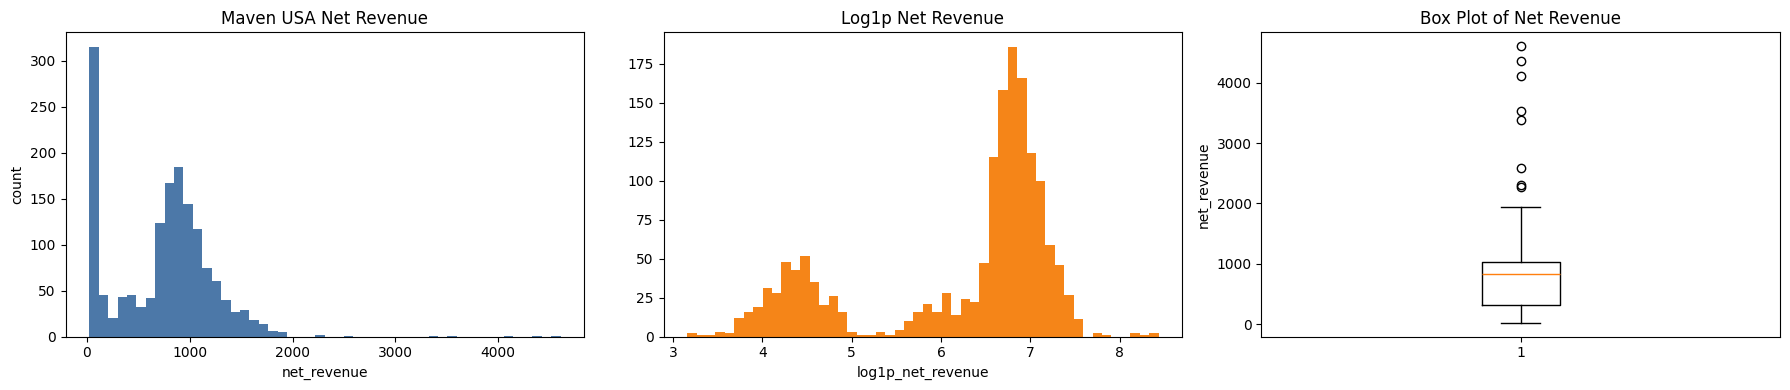

Q1=318.180, Q3=1,035.372, IQR=717.192, upper=2,111.161, outlier_pct=0.51%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(maven_us_daily["net_revenue"], bins=50, color="#4C78A8")
axes[0].set_title("Maven USA Net Revenue")
axes[0].set_xlabel("net_revenue")
axes[0].set_ylabel("count")

axes[1].hist(maven_us_daily["log1p_net_revenue"], bins=50, color="#F58518")
axes[1].set_title("Log1p Net Revenue")
axes[1].set_xlabel("log1p_net_revenue")

axes[2].boxplot(maven_us_daily["net_revenue"], vert=True)
axes[2].set_title("Box Plot of Net Revenue")
axes[2].set_ylabel("net_revenue")
plt.tight_layout()
plt.show()

q1 = maven_us_daily["net_revenue"].quantile(0.25)
q3 = maven_us_daily["net_revenue"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_pct = maven_us_daily["net_revenue"].gt(upper_bound).mean() * 100
print(f"Q1={q1:,.3f}, Q3={q3:,.3f}, IQR={iqr:,.3f}, upper={upper_bound:,.3f}, outlier_pct={outlier_pct:.2f}%")

## Cell 14 - Phân tích theo state, city, store type và store

,store_state,stores,rows,total_net_revenue,mean_net_revenue,median_net_revenue,return_value,revenue_share_pct,return_rate_pct
2,WA,7,840,"556,574.530",662.589,743.950,"5,518.630",47.710,0.992
0,CA,4,480,"327,031.190",681.315,796.440,"3,098.530",28.033,0.947
1,OR,2,240,"282,972.180","1,179.051","1,073.095","2,761.380",24.257,0.976


,store_type,stores,total_net_revenue,mean_net_revenue,median_net_revenue,mean_total_sqft,revenue_share_pct
4,Supermarket,6,"668,637.240",928.663,888.190,"27,078.000",57.316
0,Deluxe Supermarket,2,"324,915.830","1,353.816","1,271.320","30,776.000",27.852
1,Gourmet Supermarket,1,"97,169.960",809.750,816.305,"23,688.000",8.329
2,Mid-Size Grocery,1,"47,053.950",392.116,384.015,"29,182.000",4.034
3,Small Grocery,3,"28,800.920",80.003,77.810,"28,867.333",2.469


,store_id,store_name,store_city,store_state,store_type,first_date,last_date,total_net_revenue,mean_net_revenue,median_net_revenue,p95_net_revenue,return_value,revenue_share_pct
0,13,Store 13,Salem,OR,Deluxe Supermarket,1997-01-07,1998-12-27,"168,827.290","1,406.894","1,281.020","2,325.695","1,571.650",14.472
1,17,Store 17,Tacoma,WA,Deluxe Supermarket,1997-01-11,1998-12-29,"156,088.540","1,300.738","1,255.985","1,696.755","1,607.360",13.380
2,15,Store 15,Seattle,WA,Supermarket,1997-01-05,1998-12-16,"114,844.170",957.035,899.860,"1,428.598","1,137.290",9.845
3,11,Store 11,Portland,OR,Supermarket,1997-01-02,1998-12-30,"114,144.890",951.207,928.735,"1,317.957","1,189.730",9.785
4,24,Store 24,San Diego,CA,Supermarket,1997-01-06,1998-12-25,"110,279.590",918.997,886.475,"1,288.736","1,098.870",9.453
5,7,Store 7,Los Angeles,CA,Supermarket,1997-01-03,1998-12-20,"110,256.700",918.806,858.275,"1,314.727","1,054.840",9.451
6,3,Store 3,Bremerton,WA,Supermarket,1997-01-06,1998-12-25,"109,787.870",914.899,881.825,"1,271.938","1,090.010",9.411
7,16,Store 16,Spokane,WA,Supermarket,1997-01-13,1998-12-27,"109,324.020",911.034,872.275,"1,267.086","1,161.140",9.371
8,6,Store 6,Beverly Hills,CA,Gourmet Supermarket,1997-01-01,1998-12-28,"97,169.960",809.750,816.305,"1,121.259",944.820,8.329
9,23,Store 23,Yakima,WA,Mid-Size Grocery,1997-01-02,1998-12-26,"47,053.950",392.116,384.015,561.495,522.830,4.034


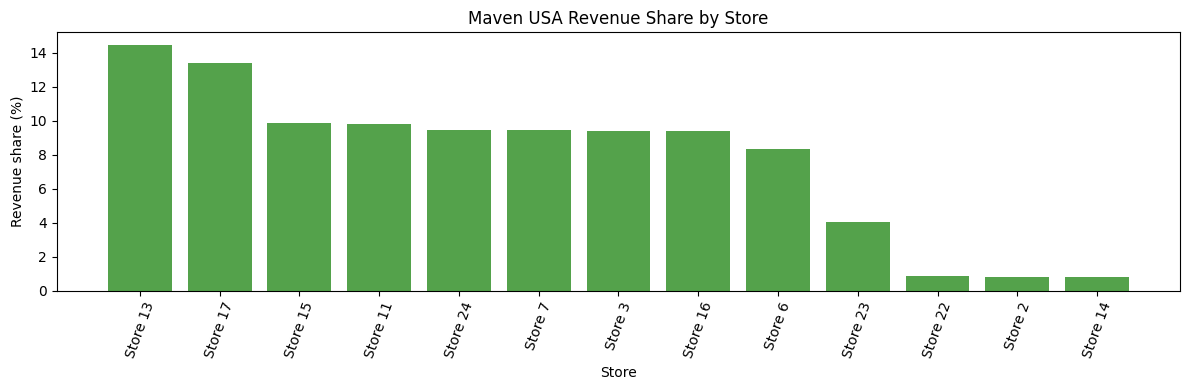

In [14]:
state_summary = (
    maven_us_daily.groupby("store_state", as_index=False)
    .agg(
        stores=("store_id", "nunique"),
        rows=("net_revenue", "size"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        return_value=("return_value", "sum"),
    )
)
state_summary["revenue_share_pct"] = state_summary["total_net_revenue"] / state_summary["total_net_revenue"].sum() * 100
state_summary["return_rate_pct"] = state_summary["return_value"] / state_summary["total_net_revenue"].replace(0, np.nan) * 100
state_summary = state_summary.sort_values("total_net_revenue", ascending=False)

display(state_summary)

store_type_summary = (
    maven_us_daily.groupby("store_type", as_index=False)
    .agg(
        stores=("store_id", "nunique"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        mean_total_sqft=("total_sqft", "mean"),
    )
)
store_type_summary["revenue_share_pct"] = store_type_summary["total_net_revenue"] / store_type_summary["total_net_revenue"].sum() * 100
store_type_summary = store_type_summary.sort_values("total_net_revenue", ascending=False)
display(store_type_summary)

store_summary = (
    maven_us_daily.groupby(["store_id", "store_name", "store_city", "store_state", "store_type"], as_index=False)
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        p95_net_revenue=("net_revenue", lambda s: s.quantile(0.95)),
        return_value=("return_value", "sum"),
    )
)
store_summary["revenue_share_pct"] = store_summary["total_net_revenue"] / store_summary["total_net_revenue"].sum() * 100
store_summary = store_summary.sort_values("total_net_revenue", ascending=False).reset_index(drop=True)
display(store_summary)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(store_summary["store_name"], store_summary["revenue_share_pct"], color="#54A24B")
ax.set_title("Maven USA Revenue Share by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Revenue share (%)")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

## Cell 15 - Trend theo thời gian

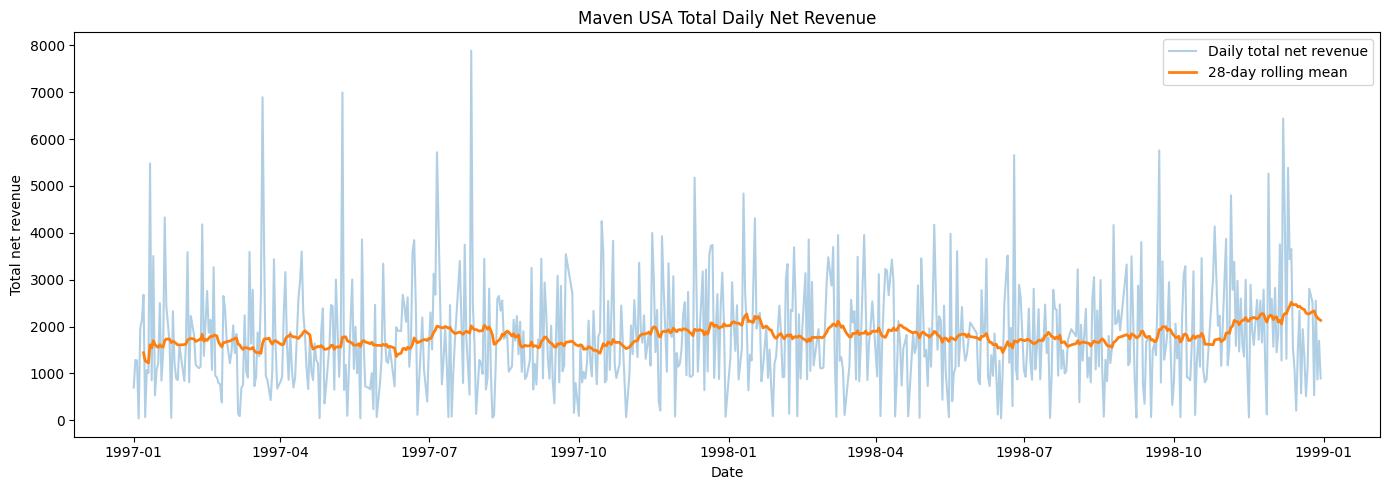

,date,total_gross_revenue,total_return_value,total_net_revenue,active_store_count,rolling_28d_net_revenue
count,649,649.000,649.000,649.000,649.000,643.000
mean,1998-01-01 04:50:39.753466,"1,815.033",17.532,"1,797.501",2.404,"1,795.552"
min,1997-01-01 00:00:00,42.650,0.000,42.650,1.000,"1,224.312"
25%,1997-06-30 00:00:00,968.170,8.180,954.090,1.000,"1,650.603"
50%,1998-01-03 00:00:00,"1,602.600",15.780,"1,585.900",2.000,"1,773.183"
75%,1998-07-05 00:00:00,"2,481.090",25.330,"2,457.880",3.000,"1,905.662"
max,1998-12-30 00:00:00,"7,959.010",74.120,"7,884.890",6.000,"2,518.549"
std,NaN,"1,163.414",13.176,"1,152.347",1.199,204.588


In [15]:
maven_us_total_daily = (
    maven_us_daily.groupby("date", as_index=False)
    .agg(
        total_gross_revenue=("gross_revenue", "sum"),
        total_return_value=("return_value", "sum"),
        total_net_revenue=("net_revenue", "sum"),
        active_store_count=("has_sales", "sum"),
    )
    .sort_values("date")
)
maven_us_total_daily["rolling_28d_net_revenue"] = maven_us_total_daily["total_net_revenue"].rolling(28, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(maven_us_total_daily["date"], maven_us_total_daily["total_net_revenue"], alpha=0.35, label="Daily total net revenue")
ax.plot(maven_us_total_daily["date"], maven_us_total_daily["rolling_28d_net_revenue"], linewidth=2, label="28-day rolling mean")
ax.set_title("Maven USA Total Daily Net Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Total net revenue")
ax.legend()
plt.tight_layout()
plt.show()

display(maven_us_total_daily.describe())

## Cell 16 - Weekday và month effect

,day_of_week,day_of_week_num,mean_net_revenue,median_net_revenue,total_net_revenue,rows
1,Monday,0,782.168,847.800,"179,116.500",229
5,Tuesday,1,687.092,786.685,"152,534.420",222
6,Wednesday,2,707.257,797.270,"152,767.430",216
4,Thursday,3,768.785,832.820,"180,664.450",235
0,Friday,4,753.315,781.055,"155,182.820",206
2,Saturday,5,769.480,850.345,"175,441.550",228
3,Sunday,6,762.816,814.945,"170,870.730",224


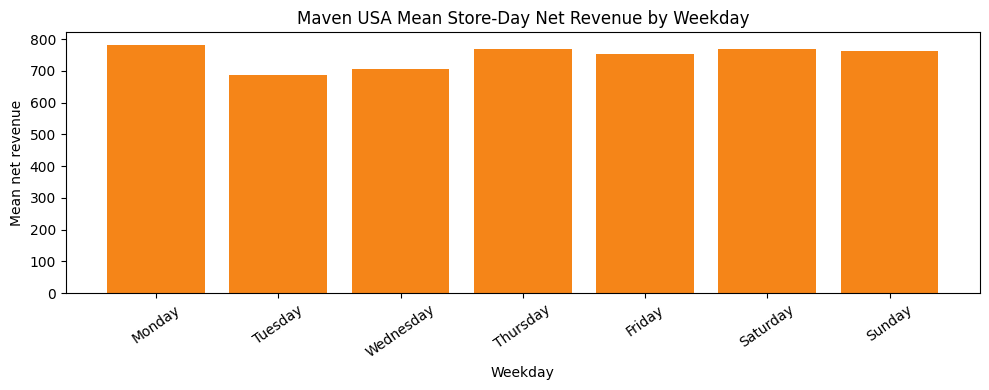

,month,mean_net_revenue,median_net_revenue,total_net_revenue
0,1,722.882,795.430,"93,974.720"
1,2,697.617,809.315,"90,690.260"
2,3,773.589,835.260,"100,566.530"
3,4,697.239,786.570,"90,641.060"
4,5,704.189,730.165,"91,544.530"
5,6,717.442,788.165,"93,267.490"
6,7,737.354,789.160,"95,856.010"
7,8,719.791,880.735,"93,572.860"
8,9,718.229,804.585,"93,369.780"
9,10,670.196,797.120,"87,125.490"


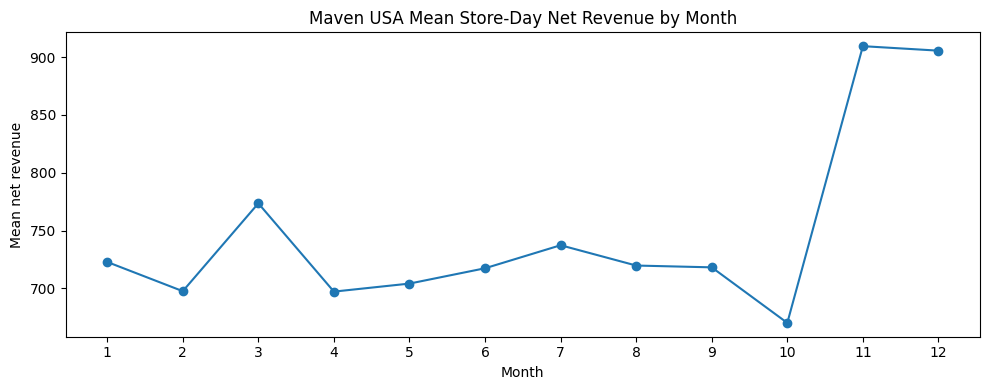

In [16]:
weekday_summary = (
    maven_us_daily.groupby(["day_of_week", "day_of_week_num"], as_index=False)
    .agg(
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_net_revenue=("net_revenue", "sum"),
        rows=("net_revenue", "size"),
    )
    .sort_values("day_of_week_num")
)
display(weekday_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(weekday_summary["day_of_week"], weekday_summary["mean_net_revenue"], color="#F58518")
ax.set_title("Maven USA Mean Store-Day Net Revenue by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Mean net revenue")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

month_summary = (
    maven_us_daily.groupby("month", as_index=False)
    .agg(
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_net_revenue=("net_revenue", "sum"),
    )
)
display(month_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_summary["month"], month_summary["mean_net_revenue"], marker="o")
ax.set_title("Maven USA Mean Store-Day Net Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean net revenue")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Cell 17 - Brand analysis USA

Brand dùng để phân tích sản phẩm, nhưng không tương đương `dept_id` của M5.

store_brand_daily_us: (80215, 10)


,product_brand,rows,total_net_revenue,mean_net_revenue,median_net_revenue,total_quantity,product_count,return_value,revenue_share_pct
0,Hermanos,1355,"38,235.280",28.218,25.440,16869,20,463.520,3.278
1,Tell Tale,1319,"34,317.640",26.018,23.040,15972,19,348.410,2.942
2,Ebony,1316,"32,487.240",24.686,21.315,15507,20,295.650,2.785
3,Tri-State,1286,"32,394.200",25.190,21.690,15465,19,311.580,2.777
4,High Top,1325,"30,699.090",23.169,20.450,14525,20,266.550,2.632
5,Nationeel,1279,"30,213.640",23.623,20.380,13478,13,325.300,2.590
6,Horatio,1250,"28,308.260",22.647,20.320,12648,13,387.890,2.427
7,Best Choice,1262,"27,849.710",22.068,18.885,12216,15,240.070,2.387
8,Red Wing,1255,"26,888.510",21.425,18.580,12138,13,289.940,2.305
9,High Quality,1226,"26,874.860",21.921,19.235,11290,14,262.020,2.304


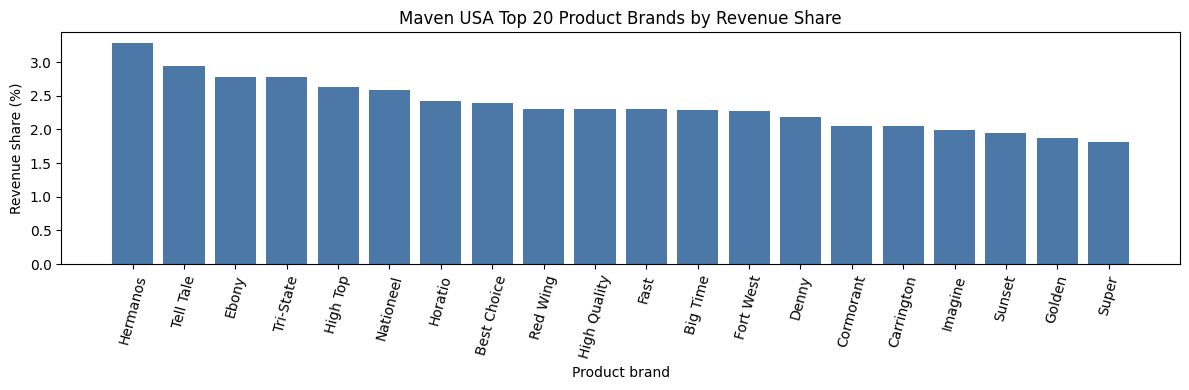

In [17]:
sales_brand_daily_us = (
    line_items_us.groupby(["transaction_date", "store_id", "product_brand"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        quantity_sold=("quantity", "sum"),
        product_count=("product_id", "nunique"),
        line_item_count=("product_id", "size"),
    )
    .rename(columns={"transaction_date": "date"})
)

returns_brand_daily_us = (
    returns_us.groupby(["return_date", "store_id", "product_brand"], as_index=False)
    .agg(
        return_value=("return_value", "sum"),
        return_quantity=("quantity", "sum"),
    )
    .rename(columns={"return_date": "date"})
)

store_brand_daily_us = sales_brand_daily_us.merge(returns_brand_daily_us, on=["date", "store_id", "product_brand"], how="left", validate="one_to_one")
store_brand_daily_us[["return_value", "return_quantity"]] = store_brand_daily_us[["return_value", "return_quantity"]].fillna(0)
store_brand_daily_us["net_revenue"] = store_brand_daily_us["gross_revenue"] - store_brand_daily_us["return_value"]

brand_summary = (
    store_brand_daily_us.groupby("product_brand", as_index=False)
    .agg(
        rows=("net_revenue", "size"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_quantity=("quantity_sold", "sum"),
        product_count=("product_count", "max"),
        return_value=("return_value", "sum"),
    )
)
brand_summary["revenue_share_pct"] = brand_summary["total_net_revenue"] / brand_summary["total_net_revenue"].sum() * 100
brand_summary = brand_summary.sort_values("total_net_revenue", ascending=False).reset_index(drop=True)

print("store_brand_daily_us:", store_brand_daily_us.shape)
display(brand_summary.head(20))

fig, ax = plt.subplots(figsize=(12, 4))
top20 = brand_summary.head(20)
ax.bar(top20["product_brand"], top20["revenue_share_pct"], color="#4C78A8")
ax.set_title("Maven USA Top 20 Product Brands by Revenue Share")
ax.set_xlabel("Product brand")
ax.set_ylabel("Revenue share (%)")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

## Cell 18 - Bootstrap confidence interval

In [18]:
def bootstrap_mean_ci(values, n_boot=1000, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means[i] = sample.mean()
    alpha = (1 - ci) / 2
    return values.mean(), np.quantile(boot_means, alpha), np.quantile(boot_means, 1 - alpha)

overall_mean, overall_low, overall_high = bootstrap_mean_ci(maven_us_daily["net_revenue"], n_boot=500)
print(f"Overall mean net revenue per USA store-day: {overall_mean:,.3f}")
print(f"95% bootstrap CI: [{overall_low:,.3f}, {overall_high:,.3f}]")

bootstrap_by_state = []
for state, group in maven_us_daily.groupby("store_state"):
    mean_v, low_v, high_v = bootstrap_mean_ci(group["net_revenue"], n_boot=300, random_state=42)
    bootstrap_by_state.append((state, mean_v, low_v, high_v))
bootstrap_by_state = pd.DataFrame(bootstrap_by_state, columns=["store_state", "mean_net_revenue", "ci95_low", "ci95_high"]).sort_values("mean_net_revenue", ascending=False)
display(bootstrap_by_state)

Overall mean net revenue per USA store-day: 747.806
95% bootstrap CI: [721.305, 771.004]


,store_state,mean_net_revenue,ci95_low,ci95_high
1,OR,"1,179.051","1,114.632","1,246.257"
0,CA,681.315,650.760,717.655
2,WA,662.589,628.829,699.449


## Cell 19 - Feature schema và leakage

In [19]:
feature_decision = pd.DataFrame([
    ("year/month/week/day_of_week/is_weekend", "Dùng", "Biết trước, phản ánh temporal pattern."),
    ("store_id/store_state/store_type/store_city", "Dùng", "Store/location effect biết trước."),
    ("sales_region/sales_district", "Dùng", "Vùng bán hàng biết trước."),
    ("total_sqft/grocery_sqft/grocery_sqft_ratio", "Dùng", "Đặc điểm cửa hàng biết trước."),
    ("store_age_years/days_since_remodel", "Dùng", "Tính được từ date và metadata store."),
    ("gross_revenue", "Không dùng", "Thành phần trực tiếp của net_revenue."),
    ("return_value", "Không dùng baseline", "Return cùng ngày là hậu nghiệm."),
    ("quantity_sold/line_item_count", "Không dùng", "Thông tin sau bán hàng, leakage mạnh."),
    ("distinct_customers/distinct_products_sold", "Không dùng baseline", "Biết sau khi ngày bán xảy ra."),
    ("product_brand", "Cẩn thận", "Chỉ dùng nếu target là store-brand-day; không tương đương dept_id của M5."),
    ("log1p_net_revenue", "Target transform", "Không phải feature."),
], columns=["field_or_group", "decision", "reason"])

display(feature_decision)

safe_features_store_daily = [
    "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "day_of_week_num", "is_weekend",
    "store_id", "store_type", "store_city", "store_state", "sales_district", "sales_region",
    "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "store_age_years", "days_since_remodel",
]
print("Target: net_revenue")
print("Safe baseline features:")
print(safe_features_store_daily)

,field_or_group,decision,reason
0,year/month/week/day_of_week/is_weekend,Dùng,"Biết trước, phản ánh temporal pattern."
1,store_id/store_state/store_type/store_city,Dùng,Store/location effect biết trước.
2,sales_region/sales_district,Dùng,Vùng bán hàng biết trước.
3,total_sqft/grocery_sqft/grocery_sqft_ratio,Dùng,Đặc điểm cửa hàng biết trước.
4,store_age_years/days_since_remodel,Dùng,Tính được từ date và metadata store.
5,gross_revenue,Không dùng,Thành phần trực tiếp của net_revenue.
6,return_value,Không dùng baseline,Return cùng ngày là hậu nghiệm.
7,quantity_sold/line_item_count,Không dùng,"Thông tin sau bán hàng, leakage mạnh."
8,distinct_customers/distinct_products_sold,Không dùng baseline,Biết sau khi ngày bán xảy ra.
9,product_brand,Cẩn thận,Chỉ dùng nếu target là store-brand-day; không ...


Target: net_revenue
Safe baseline features:
['year', 'month', 'quarter', 'week_of_year', 'day_of_month', 'day_of_year', 'day_of_week_num', 'is_weekend', 'store_id', 'store_type', 'store_city', 'store_state', 'sales_district', 'sales_region', 'total_sqft', 'grocery_sqft', 'grocery_sqft_ratio', 'store_age_years', 'days_since_remodel']


## Cell 20 - Nhận xét sau khi chạy output

In [20]:
mean_revenue = maven_us_daily["net_revenue"].mean()
median_revenue = maven_us_daily["net_revenue"].median()
mean_median_ratio = mean_revenue / median_revenue if median_revenue else np.nan

q1 = maven_us_daily["net_revenue"].quantile(0.25)
q3 = maven_us_daily["net_revenue"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_pct = maven_us_daily["net_revenue"].gt(upper_bound).mean() * 100

top_state = state_summary.iloc[0]
top_store = store_summary.iloc[0]
top_store_type = store_type_summary.iloc[0]
top_brand = brand_summary.iloc[0]
return_rate = maven_us_daily["return_value"].sum() / maven_us_daily["gross_revenue"].sum() * 100
panel_zero_pct = usa_panel["gross_revenue"].eq(0).mean() * 100
weekday_max = weekday_summary.loc[weekday_summary["mean_net_revenue"].idxmax()]
weekday_min = weekday_summary.loc[weekday_summary["mean_net_revenue"].idxmin()]

post_run_findings = pd.DataFrame([
    ("Scope", "USA only", f"Giữ {maven_us_daily['store_id'].nunique()} stores tại {', '.join(sorted(maven_us_daily['store_state'].unique()))}."),
    ("Join quality", "Đạt", f"Bảng chính có {len(maven_us_daily):,} observed store-day rows, không duplicate key, không missing target."),
    ("Target", "Net revenue", "net_revenue = gross_revenue - return_value."),
    ("Panel sparsity", "Cần cảnh báo", f"Nếu tạo panel date-store đầy đủ, zero gross revenue = {panel_zero_pct:.2f}%. Không nên xem tất cả là zero thật."),
    ("Target distribution", "Tương đối cân bằng" if 0.85 <= mean_median_ratio <= 1.15 else "Có lệch", f"Mean/median = {mean_median_ratio:.2f}; high outlier rows theo IQR = {outlier_pct:.2f}%."),
    ("Return impact", "Nhỏ nhưng nên giữ", f"Return value rate khoảng {return_rate:.2f}% gross revenue."),
    ("State effect", "Rõ", f"Top state {top_state['store_state']} chiếm {top_state['revenue_share_pct']:.2f}% net revenue."),
    ("Store effect", "Rõ", f"Top store {top_store['store_name']} chiếm {top_store['revenue_share_pct']:.2f}% net revenue."),
    ("Store type effect", "Rõ", f"Top store type {top_store_type['store_type']} chiếm {top_store_type['revenue_share_pct']:.2f}% net revenue."),
    ("Weekday effect", "Có tín hiệu", f"Ngày mean cao nhất là {weekday_max['day_of_week']}, thấp nhất là {weekday_min['day_of_week']}."),
    ("Brand effect", "Có nhưng không tương đương M5 dept", f"Top brand {top_brand['product_brand']} chiếm {top_brand['revenue_share_pct']:.2f}% net revenue."),
    ("Modeling warning", "Leakage risk", "Không dùng quantity_sold, line_item_count, distinct_customers, gross_revenue, return_value làm feature baseline."),
], columns=["aspect", "assessment", "evidence"])

display(post_run_findings)

print("Hướng đi tiếp theo:")
steps = [
    "1. Dùng Maven USA làm dataset có scope gần hơn với M5: US retail/grocery daily revenue.",
    "2. Baseline model Maven: time + store metadata + location metadata -> net_revenue.",
    "3. Không ép Maven vào product-group scope như M5 vì Maven chỉ có product_brand, không có dept/category chuẩn.",
    "4. Khi chuẩn hóa với M5, nên ưu tiên store-day schema thay vì store-dept-day schema.",
    "5. Bước kế tiếp: cào weather theo store_city/store_state cho Maven USA và đại diện CA/TX/WI cho M5.",
]
for step in steps:
    print(step)

,aspect,assessment,evidence
0,Scope,USA only,"Giữ 13 stores tại CA, OR, WA."
1,Join quality,Đạt,"Bảng chính có 1,560 observed store-day rows, k..."
2,Target,Net revenue,net_revenue = gross_revenue - return_value.
3,Panel sparsity,Cần cảnh báo,"Nếu tạo panel date-store đầy đủ, zero gross re..."
4,Target distribution,Tương đối cân bằng,Mean/median = 0.91; high outlier rows theo IQR...
5,Return impact,Nhỏ nhưng nên giữ,Return value rate khoảng 0.97% gross revenue.
6,State effect,Rõ,Top state WA chiếm 47.71% net revenue.
7,Store effect,Rõ,Top store Store 13 chiếm 14.47% net revenue.
8,Store type effect,Rõ,Top store type Supermarket chiếm 57.32% net re...
9,Weekday effect,Có tín hiệu,"Ngày mean cao nhất là Monday, thấp nhất là Tue..."


Hướng đi tiếp theo:
1. Dùng Maven USA làm dataset có scope gần hơn với M5: US retail/grocery daily revenue.
2. Baseline model Maven: time + store metadata + location metadata -> net_revenue.
3. Không ép Maven vào product-group scope như M5 vì Maven chỉ có product_brand, không có dept/category chuẩn.
4. Khi chuẩn hóa với M5, nên ưu tiên store-day schema thay vì store-dept-day schema.
5. Bước kế tiếp: cào weather theo store_city/store_state cho Maven USA và đại diện CA/TX/WI cho M5.


## Cell 21 - Optional export

Chưa tự động lưu CSV. Khi muốn lưu bảng clean, đổi `EXPORT_CSV = True`.

In [21]:
EXPORT_CSV = False
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "maven_us_store_daily_clean.csv"

if EXPORT_CSV:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    maven_us_daily.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
    print("Saved to:", OUTPUT_PATH)
else:
    print("EXPORT_CSV = False, chưa lưu CSV.")
    print("Nếu muốn lưu, đổi EXPORT_CSV = True rồi chạy lại cell này.")

EXPORT_CSV = False, chưa lưu CSV.
Nếu muốn lưu, đổi EXPORT_CSV = True rồi chạy lại cell này.
